<div style="background:linear-gradient(135deg,#1a3a5c,#2980b9);border-radius:12px;padding:30px;text-align:center;margin-bottom:20px;">
  <h1 style="color:white;margin:0;font-size:32px;letter-spacing:1px;">Omar Gamal ElKady</h1>
  <p style="color:#cce4ff;margin:8px 0 4px;font-size:16px;">ITI Intake 46 &mdash; Track AI</p>
  <hr style="border:1px solid rgba(255,255,255,0.3);width:50%;margin:14px auto;">
  <h2 style="color:white;margin:0;font-size:24px;font-weight:400;">Lab 2: Exponential Smoothing &amp; ETS Models</h2>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:10px;padding:20px;margin-bottom:15px;">
  <h3 style="color:#2e6da4;margin:0 0 12px;text-align:center;">Lab Roadmap</h3>
  <table border="0" cellpadding="10" cellspacing="0" style="border-collapse:collapse;width:100%;font-size:14px;color:#000;">
    <thead>
      <tr style="background:#2e6da4;color:white;">
        <th style="border-radius:6px 0 0 0;padding:10px;">#</th>
        <th>Section</th><th>Focus</th><th style="border-radius:0 6px 0 0;">Goal</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">1</td><td>Data Preparation</td><td style="text-align:center;">Tasks 1&ndash;3</td><td>Load the Delhi climate series, convert the date index, and enforce daily frequency.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">2</td><td>Classical Decomposition</td><td style="text-align:center;">Task 4</td><td>Inspect yearly seasonality and diagnose the decomposition residuals.</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">3</td><td>Exponential Smoothing</td><td style="text-align:center;">Tasks 5&ndash;7</td><td>Compare SES, Holt, and Holt-Winters for level, trend, and seasonal structure.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">4</td><td>ETS State-Space</td><td style="text-align:center;">Tasks 8&ndash;10</td><td>Build a formal ETS model, forecast the test horizon, and compare RMSE.</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">5</td><td>Automated ETS</td><td style="text-align:center;">Further Analysis 1</td><td>Evaluate whether AutoETS can recover an appropriate model specification.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">6</td><td>MSTL Analysis</td><td style="text-align:center;">Further Analysis 2</td><td>Use multi-seasonal decomposition to capture structure missed by the classical approach.</td></tr>
    </tbody>
  </table>
</div>

<!-- <div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">This lab applies state-space thinking to the <strong>Daily Climate Delhi</strong> series, moving from exploratory decomposition to smoothing models, ETS forecasting, automated model selection, and MSTL-based residual analysis.</p> -->
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:15px 24px;margin:20px 0 10px;"><h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 1: Import Necessary Libraries</h2></div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Import the standard data science and <strong>statsmodels</strong> libraries for Exponential Smoothing.</p>
</div>


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from statsmodels:
# - seasonal_decompose
# - SimpleExpSmoothing, Holt, ExponentialSmoothing (from statsmodels.tsa.holtwinters)
# - ETSModel (from statsmodels.tsa.exponential_smoothing.ets)

# Your imports here:
import seaborn as sns
import warnings as Warnings
from sklearn.metrics import mean_squared_error
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, MSTL
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

Warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['axes.grid'] = True


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 2: Load the Dataset</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.9;">
    <li>We are using the <strong>sumanthvrao/daily-climate-time-series-data</strong> dataset. </li>
    <li>We are interested in the <strong>meantemp</strong> column.</li>
  </ul>
</div>


In [33]:
# import kagglehub

# path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data", output_dir="dataset/")
# print("Path to dataset files:", path)

In [34]:
# TODO 2: Load the 'DailyDelhiClimateTrain.csv' dataset using pandas.
df = pd.read_csv('dataset/DailyDelhiClimateTrain.csv')

# Display first few rows and check for data types.
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nShape:", df.shape)


         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000

Data Types:
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

Shape: (1462, 5)


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 2 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The dataset contains <strong>1,462 daily observations</strong> with 5 columns: <code>date</code>, <code>meantemp</code>, <code>humidity</code>, <code>wind_speed</code>, and <code>meanpressure</code>.</li>
    <li>All weather variables are already numeric, while <code>date</code> is still stored as text and should be converted for time-series modelling.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 3: Indexing &amp; Frequency</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">ETS models in statsmodels require a clear frequency (e.g., <code style="background:#e8f0fe;padding:2px 6px;border-radius:4px;">'D'</code> for Daily) and a DatetimeIndex.</p>
</div>


In [35]:
# TODO 3.1: Convert 'date' to datetime and set it as the index.
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# TODO 3.2: Set the frequency to 'D' (Daily). Use .asfreq('D') if necessary.
temp_series = df['meantemp'].asfreq('D')

# Check for missing values after setting frequency.
print("Missing values:", temp_series.isnull().sum())
print("Frequency:", temp_series.index.freq)
print("Date range:", temp_series.index.min(), "-->", temp_series.index.max())
print(temp_series.head())

Missing values: 0
Frequency: <Day>
Date range: 2013-01-01 00:00:00 --> 2017-01-01 00:00:00
date
2013-01-01    10.000000
2013-01-02     7.400000
2013-01-03     7.166667
2013-01-04     8.666667
2013-01-05     6.000000
Freq: D, Name: meantemp, dtype: float64


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 3 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>After converting the index and setting <code>'D'</code> frequency, the series contains <strong>no missing daily timestamps</strong>.</li>
    <li>The training span runs from <strong>2013-01-01</strong> to <strong>2017-01-01</strong>, giving almost exactly 4 years of daily data.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 4: Seasonal Decomposition</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Visualize the <strong>Error</strong>, <strong>Trend</strong>, and ,<strong>Seasonality components</strong>.</p>
</div>


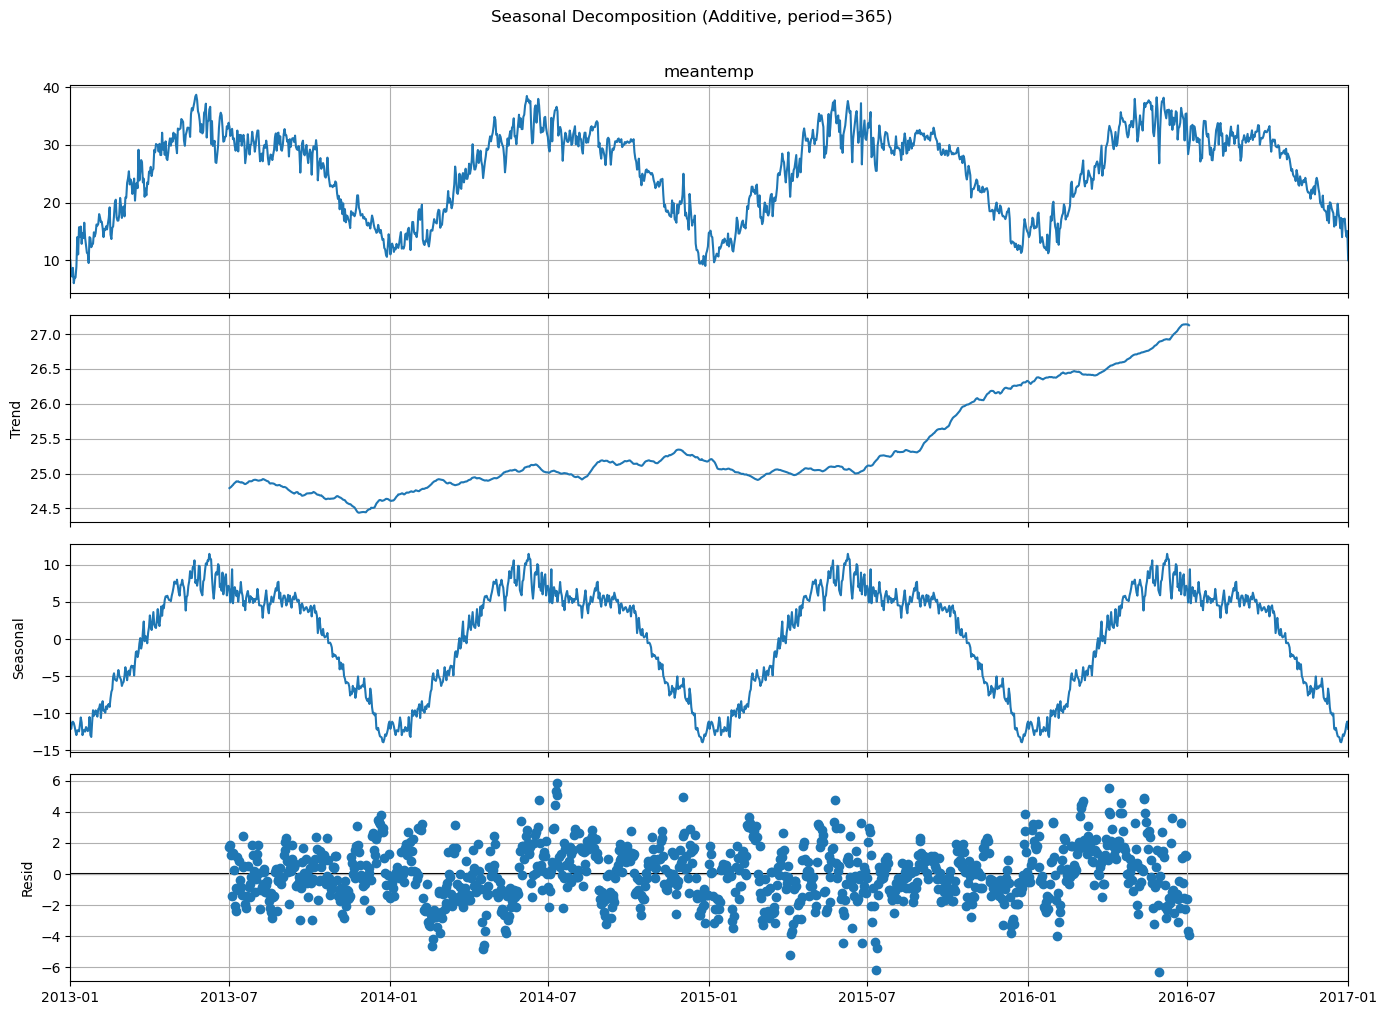

In [36]:
# TODO 4: Perform seasonal decomposition with period=365.
# Choose between 'additive' or 'multiplicative'.
# Hint: Does the seasonal variation change as the temperature increases?
# Answer: The seasonal amplitude stays roughly constant regardless of the overall
# temperature level --> Additive model is appropriate.
result_add = seasonal_decompose(temp_series, model='additive', period=365)

# Plot the results.
fig = result_add.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Seasonal Decomposition (Additive, period=365)', y=1.01)
plt.tight_layout()
plt.show()


<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">For comparison, We apply <strong>multiplicative seasonal decomposition</strong> on the same yearly period.</p>
</div>


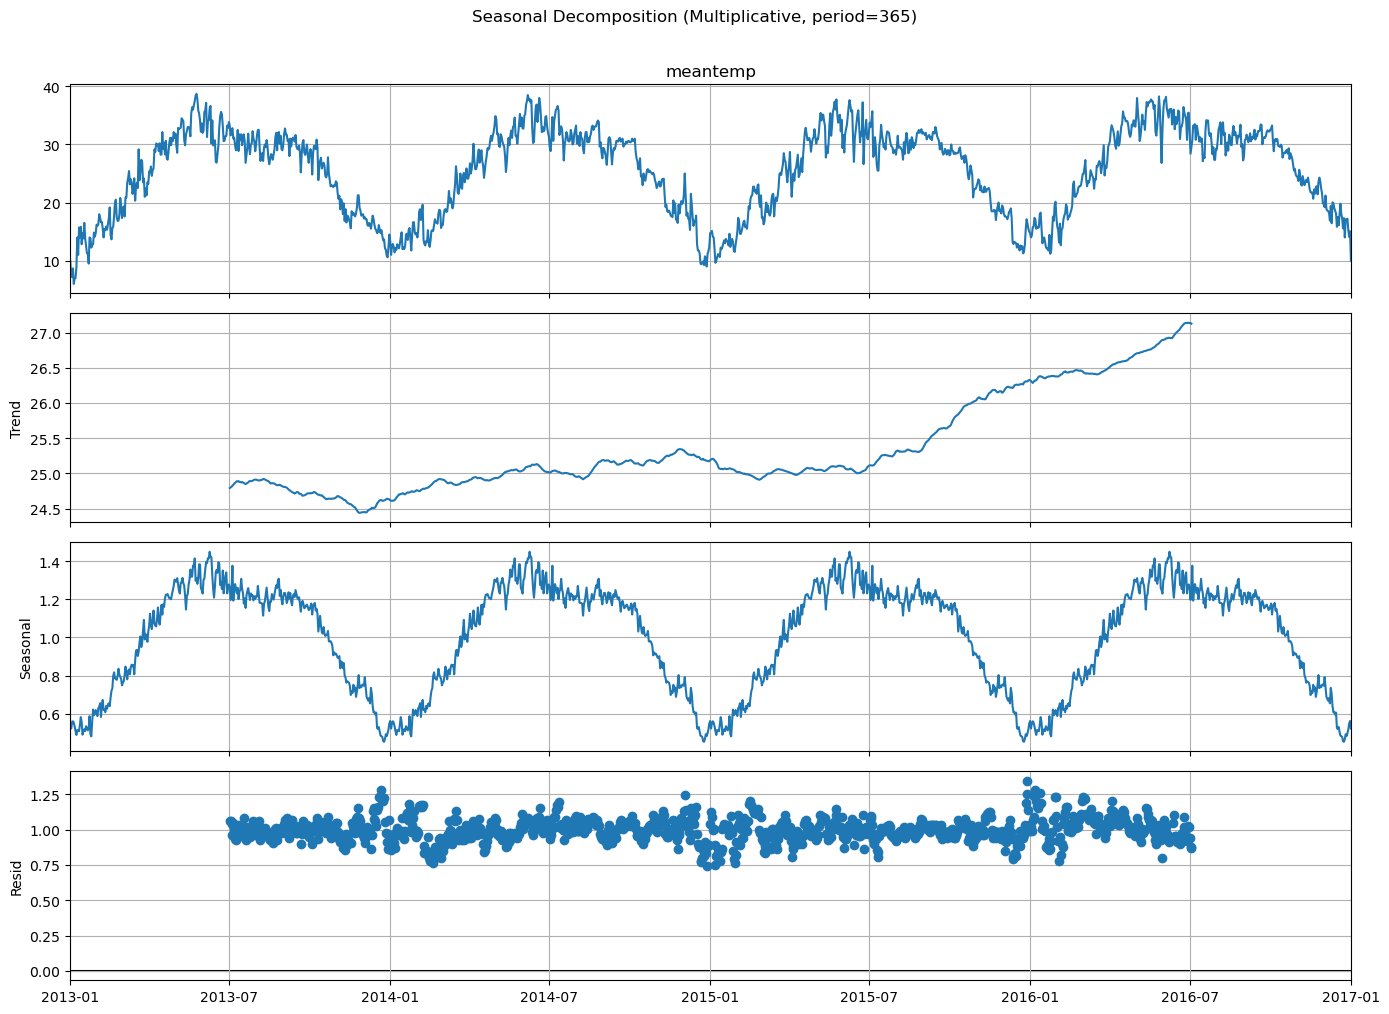

In [37]:
result_mul = seasonal_decompose(temp_series, model='multiplicative', period=365)

fig = result_mul.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Seasonal Decomposition (Multiplicative, period=365)', y=1.01)
plt.tight_layout()
plt.show()


In [38]:
def run_residual_tests(residuals, model_name):
    residuals = residuals.dropna()

    print(f"=== {model_name} Model: Ljung-Box Test ===")
    lb_result = acorr_ljungbox(residuals, return_df=True)
    print(lb_result)

    if (lb_result['lb_pvalue'] > 0.05).all():
        print("\nFail to Reject H0: Residuals are white noise — decomposition captured all temporal structure.")
    else:
        print("\nReject H0: Residuals still contain autocorrelation — decomposition did not fully capture the temporal structure.")

    print(f"\n=== {model_name} Model: Jarque-Bera Test ===")
    jb_stat, jb_pvalue, jb_skew, jb_kurt = jarque_bera(residuals)
    print(f"  Statistic : {jb_stat:.4f}")
    print(f"  p-value   : {jb_pvalue:.4f}")
    print(f"  Skewness  : {jb_skew:.4f}")
    print(f"  Kurtosis  : {jb_kurt:.4f}")

    if jb_pvalue > 0.05:
        print("\nFail to Reject H0: Residuals are normally distributed.")
    else:
        print("\nReject H0: Residuals deviate from normality.")

    return {
        'residuals': residuals,
        'lb_result': lb_result,
        'jb_stat': jb_stat,
        'jb_pvalue': jb_pvalue,
        'jb_skew': jb_skew,
        'jb_kurt': jb_kurt,
    }


In [39]:
additive_test_results = run_residual_tests(result_add.resid, 'Additive')
residuals = additive_test_results['residuals']
jb_pvalue = additive_test_results['jb_pvalue']


=== Additive Model: Ljung-Box Test ===
        lb_stat      lb_pvalue
1    591.704806  1.066818e-130
2    875.095926  9.447876e-191
3   1010.130086  1.141818e-218
4   1104.703417  7.239394e-238
5   1175.162886  7.041997e-252
6   1220.638907  1.633566e-260
7   1240.161057  1.457954e-263
8   1249.347886  2.081852e-264
9   1254.338551  2.246329e-264
10  1260.913865  1.040407e-264

Reject H0: Residuals still contain autocorrelation — decomposition did not fully capture the temporal structure.

=== Additive Model: Jarque-Bera Test ===
  Statistic : 2.1651
  p-value   : 0.3387
  Skewness  : 0.0757
  Kurtosis  : 3.1563

Fail to Reject H0: Residuals are normally distributed.


In [40]:
multiplicative_test_results = run_residual_tests(result_mul.resid, 'Multiplicative')


=== Multiplicative Model: Ljung-Box Test ===
        lb_stat      lb_pvalue
1    656.821255  7.338957e-145
2   1014.512442  5.028312e-221
3   1199.946361  7.530797e-260
4   1317.955783  4.256644e-284
5   1391.239070  1.089261e-298
6   1440.093101  5.042593e-308
7   1465.351516   0.000000e+00
8   1479.333955   0.000000e+00
9   1486.722099   0.000000e+00
10  1494.113437   0.000000e+00

Reject H0: Residuals still contain autocorrelation — decomposition did not fully capture the temporal structure.

=== Multiplicative Model: Jarque-Bera Test ===
  Statistic : 56.3760
  p-value   : 0.0000
  Skewness  : 0.1838
  Kurtosis  : 4.0474

Reject H0: Residuals deviate from normality.


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 4 &mdash; Statistical Tests</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><strong>Additive model:</strong> Ljung-Box p-values are nearly zero at all tested lags, so we reject white noise and conclude that meaningful autocorrelation still remains in the residuals.</li>
    <li><strong>Additive model:</strong> Jarque-Bera gives <strong>p = 0.3387</strong>, so we fail to reject normality; the residuals are reasonably close to Gaussian.</li>
    <li><strong>Multiplicative model:</strong> Ljung-Box also gives near-zero p-values, so it likewise fails to remove the remaining serial dependence.</li>
    <li><strong>Multiplicative model:</strong> Jarque-Bera gives <strong>p = 0.0000</strong>, so we reject normality; its residuals are clearly less well-behaved than the additive model.</li>
    <li><strong>Conclusion:</strong> neither decomposition fully captures the temporal structure, but the additive model is statistically more appropriate here because its residuals are much closer to normal while the multiplicative residuals are not. Moreover, the variance stays roughly constant across seasons, and the seasonal swings do not grow in proportion to the series level or trend. That behavior supports an <strong>additive</strong> seasonal structure rather than a multiplicative one.</li></li>
    <!-- <li><strong>Model choice rationale:</strong> the variance stays roughly constant across seasons, and the seasonal swings do not grow in proportion to the series level or trend. That behavior supports an <strong>additive</strong> seasonal structure rather than a multiplicative one.</li> -->
  </ul>
</div>


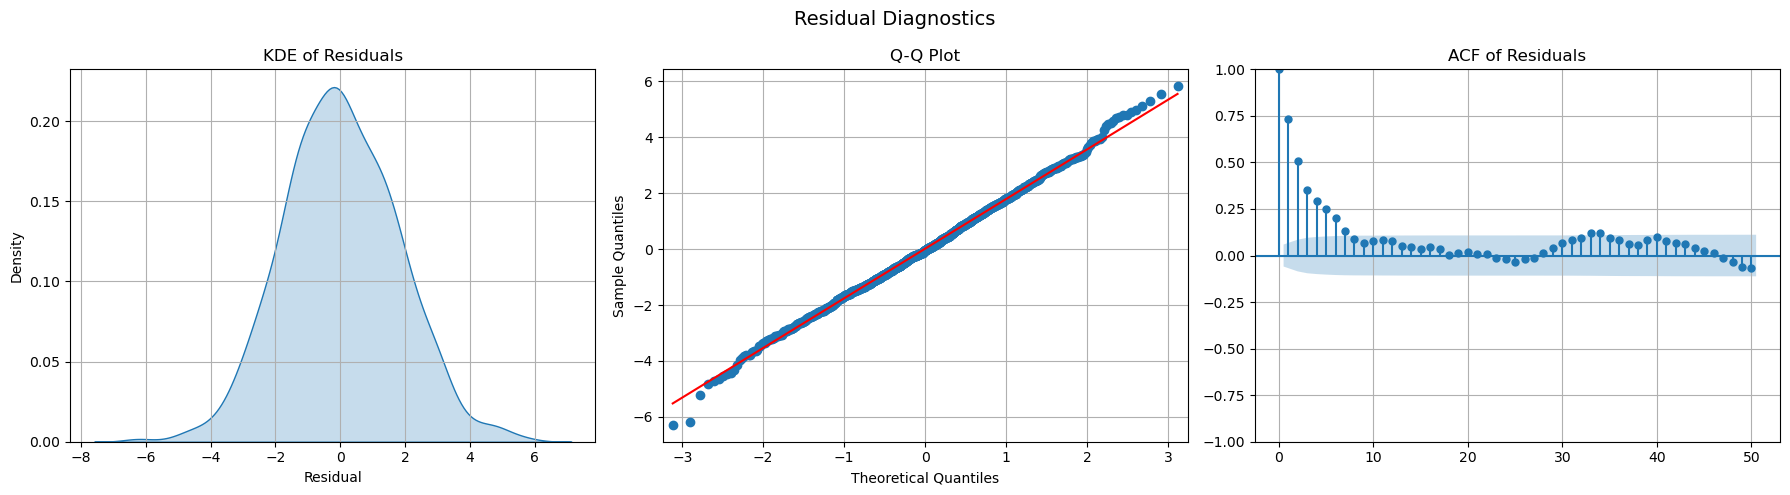

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Diagnostics', fontsize=14)

# KDE Plot
sns.kdeplot(residuals, ax=axs[0], fill=True)
axs[0].set_title('KDE of Residuals')
axs[0].set_xlabel('Residual')

# Q-Q Plot
qqplot(residuals, line='s', ax=axs[1])
axs[1].set_title('Q-Q Plot')

# ACF Plot
plot_acf(residuals, ax=axs[2], lags=50)
axs[2].set_title('ACF of Residuals')

plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 4 &mdash; Diagnostic Plots</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The <strong>KDE</strong> is roughly bell-shaped and centered close to zero, while the <strong>Q-Q plot</strong> stays near the diagonal except for mild tail deviations.</li>
    <li>Together, the <strong>KDE</strong> and <strong>Q-Q plot</strong> support the conclusion that the residuals are approximately normally distributed, which is consistent with the Jarque-Bera test.</li>
    <li>The <strong>ACF</strong> still shows notable autocorrelation across multiple lags, so the residuals are not purely white noise.</li>
    <li>This matches the <strong>Ljung-Box test</strong> which means, that the decomposition did not fully capture the temporal structure, and some predictable dependence remains in the residuals.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 5: Simple Exponential Smoothing</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">SES &mdash; Level Only</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Start with the simplest form: <strong>no trend</strong> and <strong>no seasonality</strong>.</p>
</div>


                       SimpleExpSmoothing Model Results                       
Dep. Variable:               meantemp   No. Observations:                 1462
Model:             SimpleExpSmoothing   SSE                           3941.424
Optimized:                       True   AIC                           1453.919
Trend:                           None   BIC                           1464.494
Seasonal:                        None   AICC                          1453.947
Seasonal Periods:                None   Date:                 Fri, 13 Mar 2026
Box-Cox:                        False   Time:                         14:14:23
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.7804568                alpha                 True
initial_level              9.4282054                

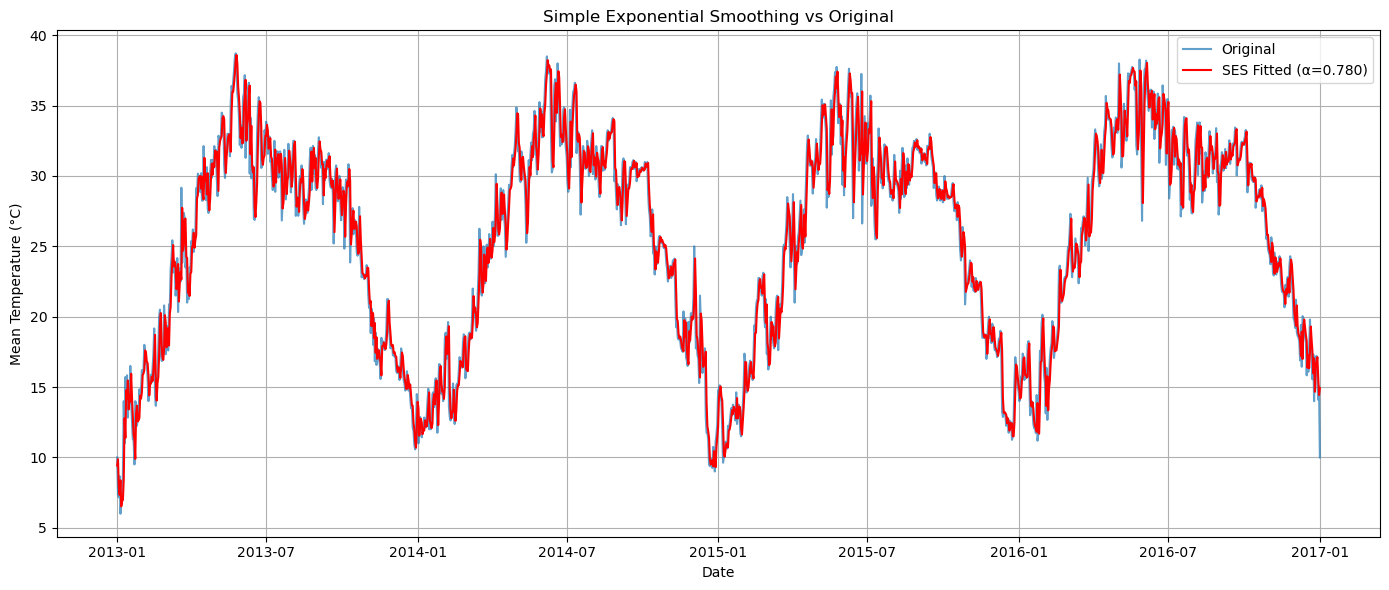

In [42]:
# TODO 5: Fit a SimpleExpSmoothing model.
# Experiment with different 'smoothing_level' (alpha) values or let it optimize automatically.
ses_model = SimpleExpSmoothing(temp_series, initialization_method='estimated').fit(optimized=True)

print(ses_model.summary())
print(f"\nOptimized alpha: {ses_model.params['smoothing_level']:.4f}")

# Plot the original series vs. the SES fitted values.
plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Original', alpha=0.7)
plt.plot(ses_model.fittedvalues, label=f"SES Fitted (α={ses_model.params['smoothing_level']:.3f})", color='red')
plt.title('Simple Exponential Smoothing vs Original')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 5 &mdash; SES Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The optimized smoothing level is <strong>&alpha; = 0.7805</strong>, which means the model heavily emphasizes the latest observation.</li>
    <li><strong>AIC = 1453.9</strong>, making SES the baseline information-criterion score for later comparisons.</li>
    <li>The fitted series follows the data with the usual one-step lag, but future forecasts collapse to a flat level because SES has no mechanism for trend or seasonal movement. From the SES equation, the forecast is just a weighted average of past observations, with much higher weight assigned to the most recent values than to older ones.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 6: Holt&rsquo;s Linear Trend Model</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Add the <strong>Trend component</strong> to handle potential long-term increases.</p>
</div>


=== Holt (Damped Trend) ===
                              Holt Model Results                              
Dep. Variable:               meantemp   No. Observations:                 1462
Model:                           Holt   SSE                           3936.389
Optimized:                       True   AIC                           1458.050
Trend:                       Additive   BIC                           1484.488
Seasonal:                        None   AICC                          1458.127
Seasonal Periods:                None   Date:                 Fri, 13 Mar 2026
Box-Cox:                        False   Time:                         14:23:58
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.7776027                alpha                 True
smoothing_trend         

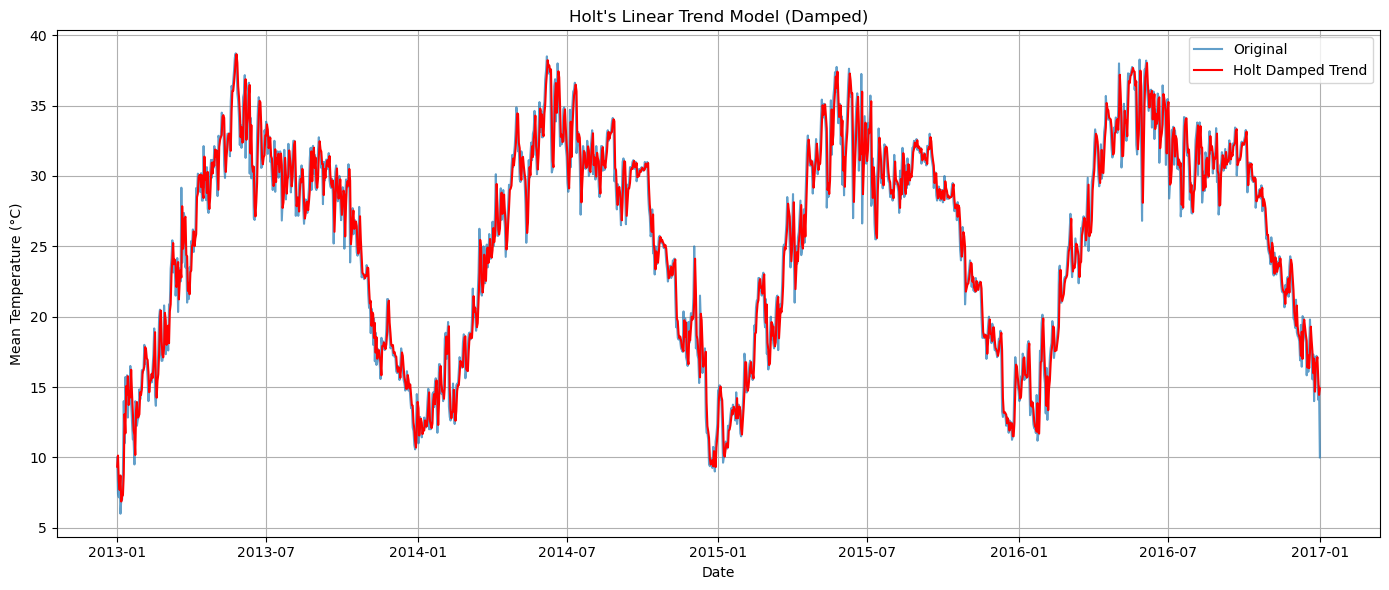

In [ ]:
# TODO 6: Fit a Holt model (ExponentialSmoothing with trend='add').
# Question: Is a damped trend necessary for climate data? Try both.
# Answer: Climate data is cyclical rather than linearly trending, so a damped trend
# is more appropriate to prevent unbounded drift in long-range forecasts.
# Also we apply AutoETS in the further analysis section and it shows that 
# the best ETS model is A,Ad,A so a damped trend is appropriate.
# but anyway the main problem is that our data is more cyclical than trending
# So this indicates that the main issue is not really the presence of a trend, 
# but rather the fact that our data is more cyclical than trending, so both models will likely perform poorly.
holt_model = Holt(temp_series, initialization_method='estimated', damped_trend=True).fit(optimized=True)

print("=== Holt (Damped Trend) ===")
print(holt_model.summary())

# Print the parameters (alpha, beta).
print("\n=== Holts Damped Model Parameters ===")
print(f"Alpha (level):    {holt_model.params['smoothing_level']:.4f}")
print(f"Beta  (trend):    {holt_model.params['smoothing_trend']:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Original', alpha=0.7)
plt.plot(holt_model.fittedvalues, label="Holt Damped Trend", color='red')
plt.title("Holt's Linear Trend Model (Damped)")
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 6 &mdash; Holt Damped Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The fitted parameters are <strong>&alpha; = 0.7776</strong>, <strong>&beta; &asymp; 0</strong>, and <strong>&phi; = 0.987</strong>.</li>
    <li>The near-zero trend update shows that the optimizer found almost no benefit in maintaining a trend state.</li>
    <li><strong>SSE = 3936.4</strong> improves only marginally over SES, while <strong>AIC = 1458.1</strong> is worse because the extra parameters are not justified (smoothing trend are nearly zero).</li>
    <li><strong>Conclusion:</strong> The data does not show a useful linear trend, because Delhi temperature here is dominated more by seasonal behavior than by a steady upward or downward movement.</li>
  </ul>
</div>


=== Holt (Undamped Trend) ===
                              Holt Model Results                              
Dep. Variable:               meantemp   No. Observations:                 1462
Model:                           Holt   SSE                           3941.421
Optimized:                       True   AIC                           1457.918
Trend:                       Additive   BIC                           1479.068
Seasonal:                        None   AICC                          1457.976
Seasonal Periods:                None   Date:                 Fri, 13 Mar 2026
Box-Cox:                        False   Time:                         14:20:12
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.7804456                alpha                 True
smoothing_trend       

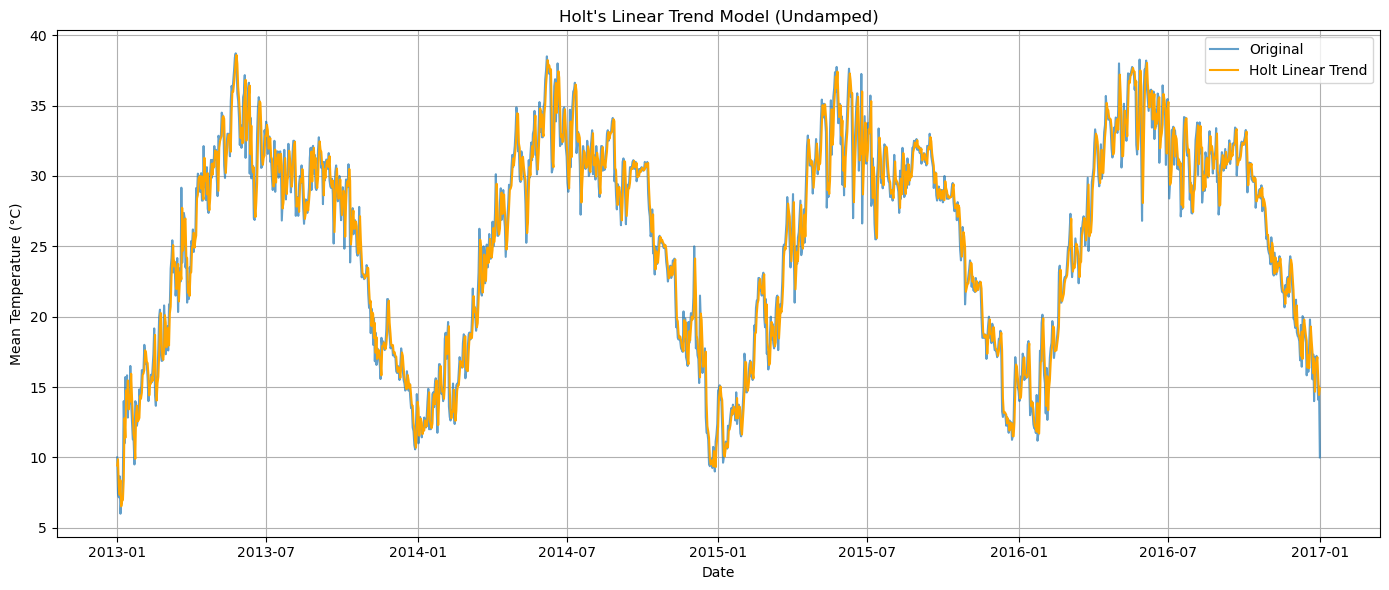

In [62]:
holt_no_damp = Holt(temp_series, initialization_method='estimated', damped_trend=False).fit(optimized=True)

print("=== Holt (Undamped Trend) ===")
print(holt_no_damp.summary())

# Print the parameters (alpha, beta).
print("\n=== Holts undamped Model Parameters ===")
print(f"Alpha (level):    {holt_no_damp.params['smoothing_level']:.4f}")
print(f"Beta  (trend):    {holt_no_damp.params['smoothing_trend']:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Original', alpha=0.7)
plt.plot(holt_no_damp.fittedvalues, label="Holt Linear Trend", color='orange')
plt.title("Holt's Linear Trend Model (Undamped)")
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 6 &mdash; Holt Undamped Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The undamped fit also drives the trend update to zero, with <strong>&beta; = 0</strong> and an almost negligible initial trend.</li>
    <li><strong>SSE = 3941.4</strong> is essentially identical to SES, and <strong>AIC = 1457.9</strong> is still worse than the simpler level-only model.</li>
    <li><strong>conclusion:</strong> Both Holt variants support the same observation, the dominant structure in this series is seasonal, not linear trend.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 7: Holt-Winters</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Triple Exponential Smoothing &mdash; Additive Trend + Additive Seasonality</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Add the Seasonality component to capture the yearly cycles.</p>
</div>


                       ExponentialSmoothing Model Results                       
Dep. Variable:                 meantemp   No. Observations:                 1462
Model:             ExponentialSmoothing   SSE                           2917.008
Optimized:                         True   AIC                           1747.881
Trend:                         Additive   BIC                           3698.991
Seasonal:                      Additive   AICC                          2001.114
Seasonal Periods:                   365   Date:                 Fri, 13 Mar 2026
Box-Cox:                          False   Time:                         14:14:26
Box-Cox Coeff.:                    None                                         
                           coeff                 code              optimized      
----------------------------------------------------------------------------------
smoothing_level                0.7733860                alpha                 True
smoothing_trend       

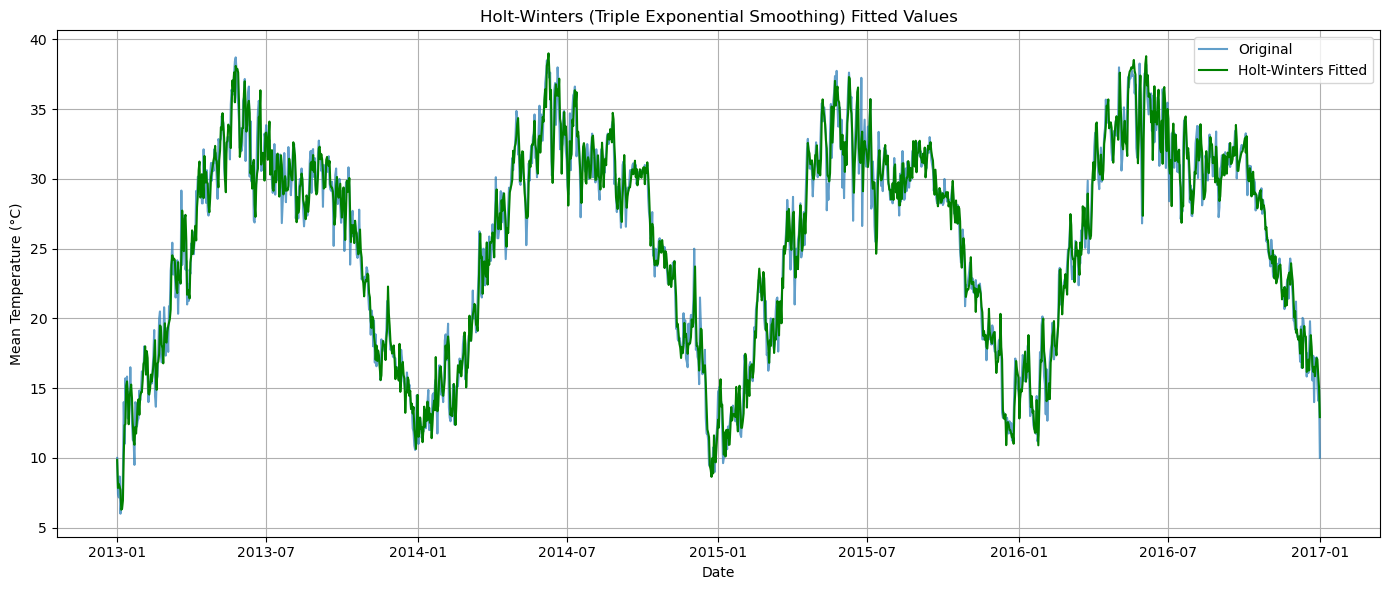

In [45]:
# TODO 7: Fit an ExponentialSmoothing model with trend='add', seasonal='add', and seasonal_periods=365.
hw_model = ExponentialSmoothing(
    temp_series,
    trend='add',
    seasonal='add',
    seasonal_periods=365,
    initialization_method='estimated'
).fit(optimized=True)

# Print the full Holt-Winters model summary.
print(hw_model.summary())

# Print the parameters (alpha, beta, gamma).
print("\n=== Holt-Winters Model Parameters ===")
print(f"Alpha (level):    {hw_model.params['smoothing_level']:.4f}")
print(f"Beta  (trend):    {hw_model.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal): {hw_model.params['smoothing_seasonal']:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Original', alpha=0.7)
plt.plot(hw_model.fittedvalues, label='Holt-Winters Fitted', color='green')
plt.title('Holt-Winters (Triple Exponential Smoothing) Fitted Values')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
len(hw_model.params['initial_seasons'])

365

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 7 &mdash; Holt-Winters Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The optimized parameters are <strong>&alpha; = 0.7734</strong>, <strong>&beta; &asymp; 0</strong>, and <strong>&gamma; &asymp; 0</strong>.</li>
    <li>The near-zero trend update again confirms no meaningful linear drift, while the near-zero seasonal update indicates the model relies heavily on the initially estimated yearly seasonal pattern.</li>
    <li>Even with minimal updating, Holt-Winters tracks the original series much more closely because the 365-day seasonal structure is now explicitly represented.</li>
    <li>From the model summary, <strong>SSE = 2917.0</strong>, which is much lower than SES and Holt, so the in-sample fit improves substantially once yearly seasonality is included.</li>
    <li>However, the summary also reports <strong>AIC = 1747.9</strong>, and <strong>BIC = 3699.0</strong>. These are much larger because Holt-Winters with <strong>365 seasonal states</strong> is far more complex and contains more parameters, so information criteria penalize it heavily.</li>
    <li><strong>Conclusion:</strong> Holt-Winters is clearly better at fitting the temperature series because the dominant signal is annual seasonality, not trend. The improvement comes from explicitly modeling the 365-day seasonal cycle, even though the information criteria remain large due to the model's high seasonal complexity.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 8: The ETS State-Space Model</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Use the formal <strong>ETSModel</strong> which allows for automated likelihood-based selection.</p>
</div>


                                 ETS Results                                  
Dep. Variable:               meantemp   No. Observations:                 1462
Model:                       ETS(AAA)   Log Likelihood               -2679.914
Date:                Fri, 13 Mar 2026   AIC                           6101.829
Time:                        14:16:11   BIC                           8063.513
Sample:                    01-01-2013   HQIC                          6833.566
                         - 01-01-2017   Scale                            2.289
Covariance Type:               approx                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
smoothing_level          0.9999      0.030     32.812      0.000       0.940       1.060
smoothing_trend       9.999e-05        nan        nan        nan         nan         nan
smoothing_se

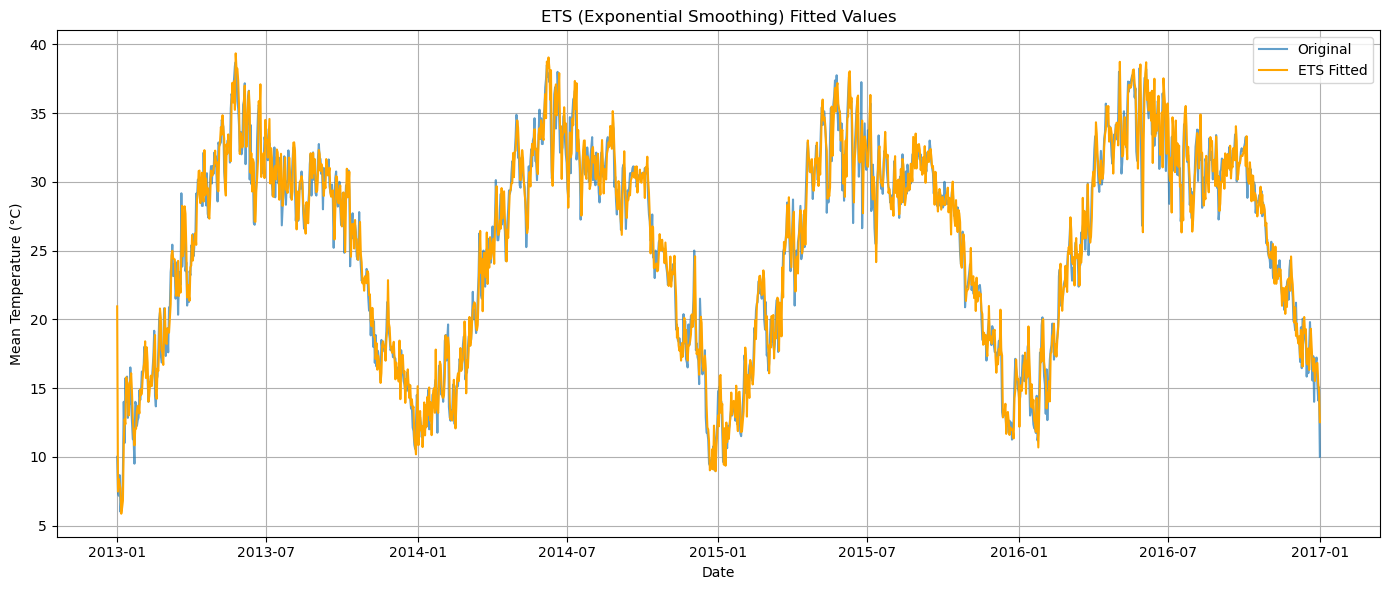

In [47]:
# TODO 8: Fit an ETSModel with error='add', trend='add', seasonal='add', and seasonal_periods=365.
ets_fit = ETSModel(temp_series, error='add', trend='add', seasonal='add', seasonal_periods=365).fit()

# Display the summary.
print(ets_fit.summary())


print("\n=== ETS Model Parameters ===")
print(f"Alpha (level):    {ets_fit.params[0]:.4f}")
print(f"Beta  (trend):    {ets_fit.params[1]:.4f}")
print(f"Gamma (seasonal): {ets_fit.params[2]:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Original', alpha=0.7)
plt.plot(ets_fit.fittedvalues, label='ETS Fitted', color='orange')
plt.title('ETS (Exponential Smoothing) Fitted Values')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
len(ets_fit.param_names)

370

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 8 &mdash; ETS State-Space Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The fitted <strong>ETS(A,A,A)</strong> model gives the smoothing estimates <strong>&alpha; = 0.9999</strong>, <strong>&beta; &asymp; 0.0001</strong>, and <strong>&gamma; &asymp; 0.0001</strong>.</li>
    <li>The near-zero trend and seasonal smoothing updates indicate that after initialization, the model barely updates the trend or seasonal states, while the almost-unit <strong>&alpha;</strong> means the level is updated very aggressively from the most recent observations.</li>
    <!-- <li>From the model summary, the fit reports <strong>log-likelihood = -2679.9</strong> and <strong>scale = 2.289</strong>, so the model is able to produce a full state-space likelihood and support prediction intervals.</li>
    <li>However, <strong>AIC = 6101.8</strong> and <strong>BIC = 8063.5</strong>. These become extremely large because ETS(A,A,A) with <strong>365 seasonal states</strong> is highly parameterized relative to only about 4 years of daily data, Because the model needed to estimate the seasonal index for every position in the seasonal cycle which make it so high</li>
    <li>The model also raises a <strong>ConvergenceWarning</strong>, and many seasonal-state coefficients have large uncertainty or non-significant p-values, which suggests that the optimization is unstable and the seasonal states are difficult to estimate reliably.</li>
    <li><strong>Conclusion:</strong> ETSModel is valuable because it provides a formal state-space formulation with likelihood-based comparison and prediction intervals, but this specific ETS(A,A,A) fit is statistically weak for our dataset because the annual seasonal state space is too large for the available sample, leading to convergence issues and heavily penalized information criteria.</li> -->
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 9: Evaluation &amp; Forecasting</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Forecast the temperature for the next <strong>30 days</strong> and compare with the provided Test set.</p>
</div>


Full test set: 2017-01-01 00:00:00 --> 2017-04-24 00:00:00 (114 days)
Evaluation window: first 30 days (2017-01-01 00:00:00 --> 2017-01-30 00:00:00)


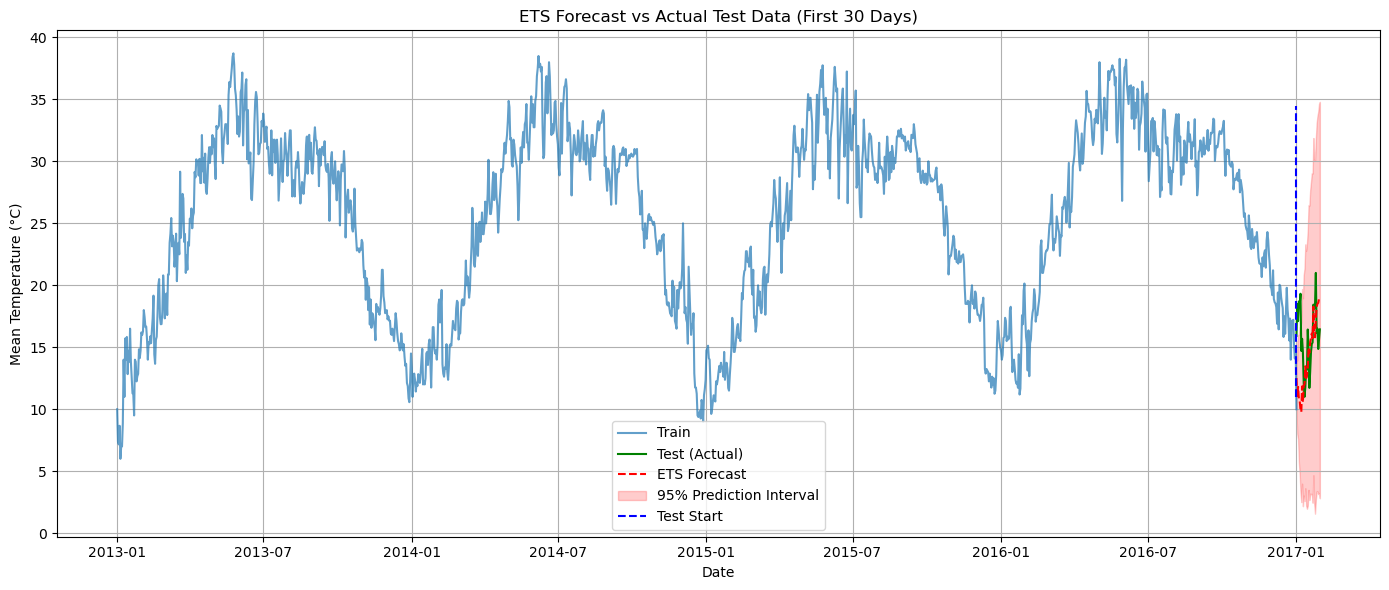

In [49]:
# TODO 9.1: Load 'DailyDelhiClimateTest.csv'.
test_df = pd.read_csv('dataset/DailyDelhiClimateTest.csv')
test_df['date'] = pd.to_datetime(test_df['date'])
test_df.set_index('date', inplace=True)
test_series_full = test_df['meantemp'].asfreq('D')
forecast_steps = 30
test_series = test_series_full.iloc[:forecast_steps]

print(f"Full test set: {test_series_full.index.min()} --> {test_series_full.index.max()} ({len(test_series_full)} days)")
print(f"Evaluation window: first {forecast_steps} days ({test_series.index.min()} --> {test_series.index.max()})")

# TODO 9.2: Generate forecasts using your best model (HW or ETSModel).
prediction = ets_fit.get_prediction(start=test_series.index[0], end=test_series.index[-1])
pred_frame = prediction.summary_frame(alpha=0.05)  # 95% prediction interval
ets_forecast = pred_frame['mean']
pred_ci_lower = pred_frame['pi_lower']
pred_ci_upper = pred_frame['pi_upper']

# TODO 9.3: Plot Train, Test, and Forecast.
# Bonus: Use get_prediction() on ETSModel to plot prediction intervals.
plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Train', alpha=0.7)
plt.plot(test_series, label='Test (Actual)', color='green')
plt.plot(ets_forecast, label='ETS Forecast', color='red', linestyle='--')
plt.fill_between(
    ets_forecast.index,
    pred_ci_lower,
    pred_ci_upper,
    alpha=0.2,
    color='red',
    label='95% Prediction Interval'
)
plt.vlines(test_series_full.index[0], ymin=test_series_full.min(), ymax=test_series_full.max(), color='blue', label='Test Start', linestyle='--')
plt.title('ETS Forecast vs Actual Test Data (First 30 Days)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 9 &mdash; ETS Forecast Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The ETS forecast is now evaluated on only the <strong>first 30 days</strong> of the test set, and over this short horizon it continues the seasonal pattern into early January with a plausible shape.</li>
    <li>The <strong>95% prediction interval</strong> still widens as the forecast moves farther away from the training endpoint, which is the expected uncertainty behaviour even within a 30-day horizon.</li>
    <li>The actual observations in this 30-day window mostly stay within the interval, so the interval calibration appears reasonable for the short-term forecast.</li>
  </ul>
</div>


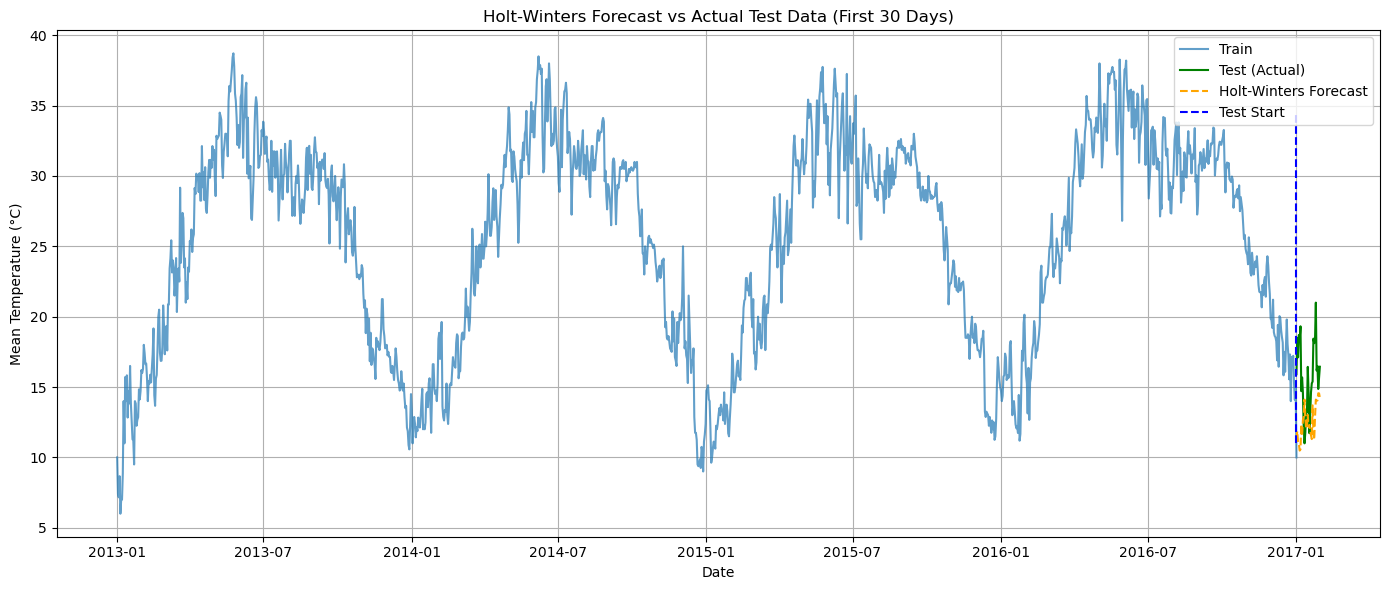

In [50]:
# Holt-Winters Forecast on Test Set
hw_forecast = hw_model.forecast(forecast_steps)
hw_forecast.index = test_series.index

plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Train', alpha=0.7)
plt.plot(test_series, label='Test (Actual)', color='green')
plt.plot(hw_forecast, label='Holt-Winters Forecast', color='orange', linestyle='--')
plt.vlines(test_series_full.index[0], ymin=test_series_full.min(), ymax=test_series_full.max(), color='blue', label='Test Start', linestyle='--')
plt.title('Holt-Winters Forecast vs Actual Test Data (First 30 Days)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 9 &mdash; Holt-Winters Forecast Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The Holt-Winters forecast is also compared on the <strong>first 30 test days</strong>, and it follows the same broad seasonal direction as ETS, indicating that both models captured the annual temperature cycle.</li>
    <li>Visually, ETS appears to capture the seasonal cycle slightly better than Holt-Winters on this 30-day window.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 10: Model Comparison</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Compare the RMSE of the Holt-Winters model vs. a simple mean baseline.</p>
</div>


In [51]:
# TODO 10: Calculate and print the RMSE for your forecast.
# Align forecast with test (in case of index overlap at boundary)
aligned_ets_forecast = ets_forecast.reindex(test_series.index)
aligned_hw = hw_forecast.reindex(test_series.index)

# ETS model RMSE
ets_rmse = np.sqrt(mean_squared_error(test_series, aligned_ets_forecast))

# Holt-Winters RMSE
hw_rmse = np.sqrt(mean_squared_error(test_series, aligned_hw))

# Baseline: simple mean of training data
mean_baseline = np.full(len(test_series), temp_series.mean())
baseline_rmse = np.sqrt(mean_squared_error(test_series, mean_baseline))

print(f"{'Model':<30} {'RMSE':>8}")
print("-" * 40)
print(f"{'Mean Baseline':<30} {baseline_rmse:>8.4f}")
print(f"{'Holt-Winters':<30} {hw_rmse:>8.4f}")
print(f"{'ETS (A,A,A)':<30} {ets_rmse:>8.4f}")
print()
best = min([('Mean Baseline', baseline_rmse), ('Holt-Winters', hw_rmse), ('ETS', ets_rmse)], key=lambda x: x[1])
print(f"Best model: {best[0]} with RMSE = {best[1]:.4f}")

Model                              RMSE
----------------------------------------
Mean Baseline                   10.1010
Holt-Winters                     4.3699
ETS (A,A,A)                      3.8806

Best model: ETS with RMSE = 3.8806


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 10 &mdash; Model Comparison Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>On the <strong>first 30 test days</strong>, <strong>ETS(A,A,A)</strong> is the best performer with <strong>RMSE = 3.8806</strong>.</li>
    <li><strong>Holt-Winters</strong> follows with <strong>RMSE = 4.3699</strong>, so it remains competitive but is slightly worse than ETS on this shorter forecast horizon.</li>
    <li>The <strong>mean baseline</strong> is much weaker at <strong>RMSE = 10.1010</strong>, confirming that explicit seasonal modelling provides substantial forecasting value even over only 30 days.</li>
    <li><strong>Conclusion:</strong> ETS performs better than Holt-Winters.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 1: Automated ETS Selection</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">AutoETS</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <!-- <p style="margin:0 0 10px;font-weight:bold;color:#2e6da4;">Why this extension matters:</p> -->
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.8;">
    <li>Instead of fixing the error, trend, and seasonal structure manually, We use <strong>AutoETS</strong> to search for the best valid specification.</li>
    <!-- <li>This mirrors practical forecasting workflows where information criteria are used to choose among competing ETS families.</li> -->
  </ul>
</div>


In [52]:
train_sf = pd.DataFrame({
    'ds': temp_series.index,
    'y': temp_series.values,
    'unique_id': 'delhi_temp'
})

sf = StatsForecast(
    models=[AutoETS(model='ZZA', season_length=365)],
    freq='D',
    n_jobs=-1
)

sf.fit(train_sf)

selected_method = sf.fitted_[0, 0].model_['method']
print(f"AutoETS selected model: {selected_method}")

AutoETS selected model: ETS(A,Ad,A)


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 1 &mdash; AutoETS Selection Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>AutoETS selected <strong>ETS(A,Ad,A)</strong>, meaning additive error, <strong>additive damped trend</strong>, and <strong>additive seasonality</strong>.</li>
    <!-- <li>This is much more reasonable than the earlier level-only interpretation, because the selected model still preserves yearly seasonality while controlling the trend through damping rather than letting it grow freely.</li> -->
    <li>The selected specification suggests that AutoETS found a seasonal model with a damped trend to be the best fit.</li>
  </ul>
</div>


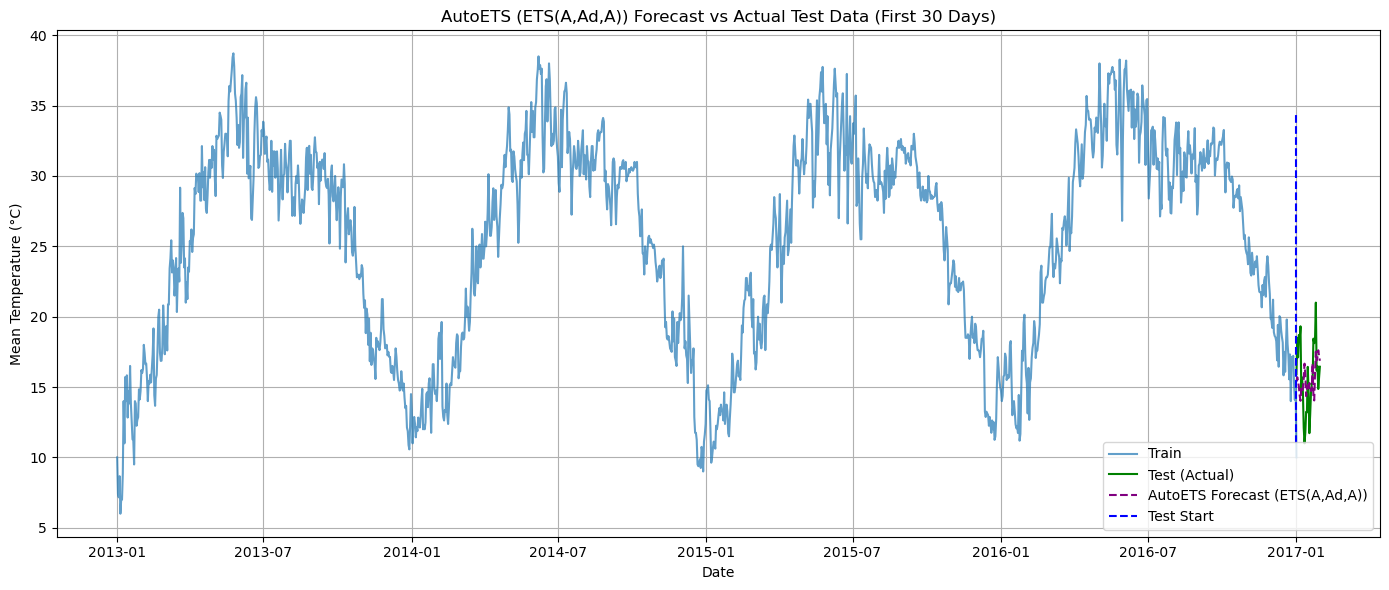

In [53]:
auto_forecast_df = sf.predict(forecast_steps)

auto_forecast = pd.Series(
    auto_forecast_df['AutoETS'].values,
    index=test_series.index,
    name='AutoETS'
)

plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Train', alpha=0.7)
plt.plot(test_series, label='Test (Actual)', color='green')
plt.plot(auto_forecast, label=f'AutoETS Forecast ({selected_method})', color='purple', linestyle='--')
plt.vlines(test_series_full.index[0], ymin=test_series_full.min(), ymax=test_series_full.max(), color='blue', label='Test Start', linestyle='--')
plt.title(f'AutoETS ({selected_method}) Forecast vs Actual Test Data (First 30 Days)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 1 &mdash; AutoETS Forecast Plot</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>With the selected <strong>ETS(A,Ad,A)</strong> model, it shows a short-term seasonal movement that follows the direction of the actual January temperatures much more closely.</li>
    <li>Visually, the forecast appears smoother than the raw test series but still preserves the seasonal structure, which is consistent with a damped-trend additive seasonal model.</li>
  </ul>
</div>


In [54]:
auto_rmse = np.sqrt(mean_squared_error(test_series, auto_forecast))

print(f"{'Model':<30} {'RMSE':>8}")
print("=" * 40)
print(f"{'Mean Baseline':<30} {baseline_rmse:>8.4f}")
print(f"{'Holt-Winters':<30} {hw_rmse:>8.4f}")
print(f"{'ETS (A,A,A)':<30} {ets_rmse:>8.4f}")
print(f"{'AutoETS ({selected_method})':<30} {auto_rmse:>8.4f}")
print("=" * 40)

all_models = [
    ('Mean Baseline', baseline_rmse),
    ('Holt-Winters', hw_rmse),
    ('ETS (A,A,A)', ets_rmse),
    (f'AutoETS ({selected_method})', auto_rmse),
]
best = min(all_models, key=lambda x: x[1])
print(f"\nBest model: {best[0]} with RMSE = {best[1]:.4f}")

Model                              RMSE
Mean Baseline                   10.1010
Holt-Winters                     4.3699
ETS (A,A,A)                      3.8806
AutoETS ({selected_method})      2.6846

Best model: AutoETS (ETS(A,Ad,A)) with RMSE = 2.6846


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 1 &mdash; AutoETS RMSE Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>On the <strong>first 30 test days</strong>, AutoETS records <strong>RMSE = 2.6846</strong>, which is the <strong>best</strong> result among all evaluated models.</li>
    <li>It outperforms <strong>ETS(A,A,A) = 3.8806</strong>, <strong>Holt-Winters = 4.3699</strong>, and the <strong>mean baseline = 10.1010</strong>, showing that the automatically selected damped-trend seasonal model generalizes very well over this short horizon.</li>
    <li><strong>Conclusion:</strong> AutoETS chooses a reasonable seasonal model <strong>ETS(A,Ad,A)</strong> and achieves the strongest short-term forecast accuracy among all compared methods.</li>
  </ul>
</div>


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 2: MSTL Decomposition</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Multi-Seasonal Trend Decomposition</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">MSTL decomposition allows <strong>multiple seasonal periods</strong>, which is useful for identifying whether the data contains more than one seasonal pattern. Because our residuals from a single yearly decomposition still exhibit remaining structure.</p>
</div>


In [55]:
mstl_df = pd.DataFrame({
    'ds': temp_series.index,
    'y': temp_series.values,
    'unique_id': 'delhi_temp'
})

mstl_pipeline = StatsForecast(
    models=[MSTL(season_length=[7, 30, 90, 120, 365])],
    freq='D',
    n_jobs=-1
)

mstl_pipeline.fit(mstl_df)

mstl_decompose = mstl_pipeline.fitted_[0, 0].model_
mstl_decompose['ds'] = temp_series.index

print("MSTL Decomposition columns:", mstl_decompose.columns.tolist())
print(mstl_decompose.head())

MSTL Decomposition columns: ['data', 'trend', 'seasonal7', 'seasonal30', 'seasonal90', 'seasonal120', 'seasonal365', 'remainder', 'ds']
        data      trend  seasonal7  seasonal30  seasonal90  seasonal120  \
0  10.000000  24.877148  -0.276034    0.322064   -0.483451    -0.583106   
1   7.400000  24.876882   0.816921   -0.552906   -0.915145    -0.970741   
2   7.166667  24.876613   0.709487   -0.750359   -0.739249    -1.329075   
3   8.666667  24.876340   0.577706    0.491221   -0.993149    -0.455306   
4   6.000000  24.876063  -0.703261    0.794281   -0.706600    -0.870630   

   seasonal365  remainder         ds  
0   -12.177371  -1.679250 2013-01-01  
1   -13.796893  -2.058118 2013-01-02  
2   -12.560266  -3.040484 2013-01-03  
3   -12.324315  -3.505830 2013-01-04  
4   -13.513763  -3.876091 2013-01-05  


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; MSTL Fit Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>MSTL decomposed the series into the original data, a trend component, and <strong>five seasonal patterns</strong> with periods 7, 30, 90, 120, and 365.</li>
  </ul>
</div>


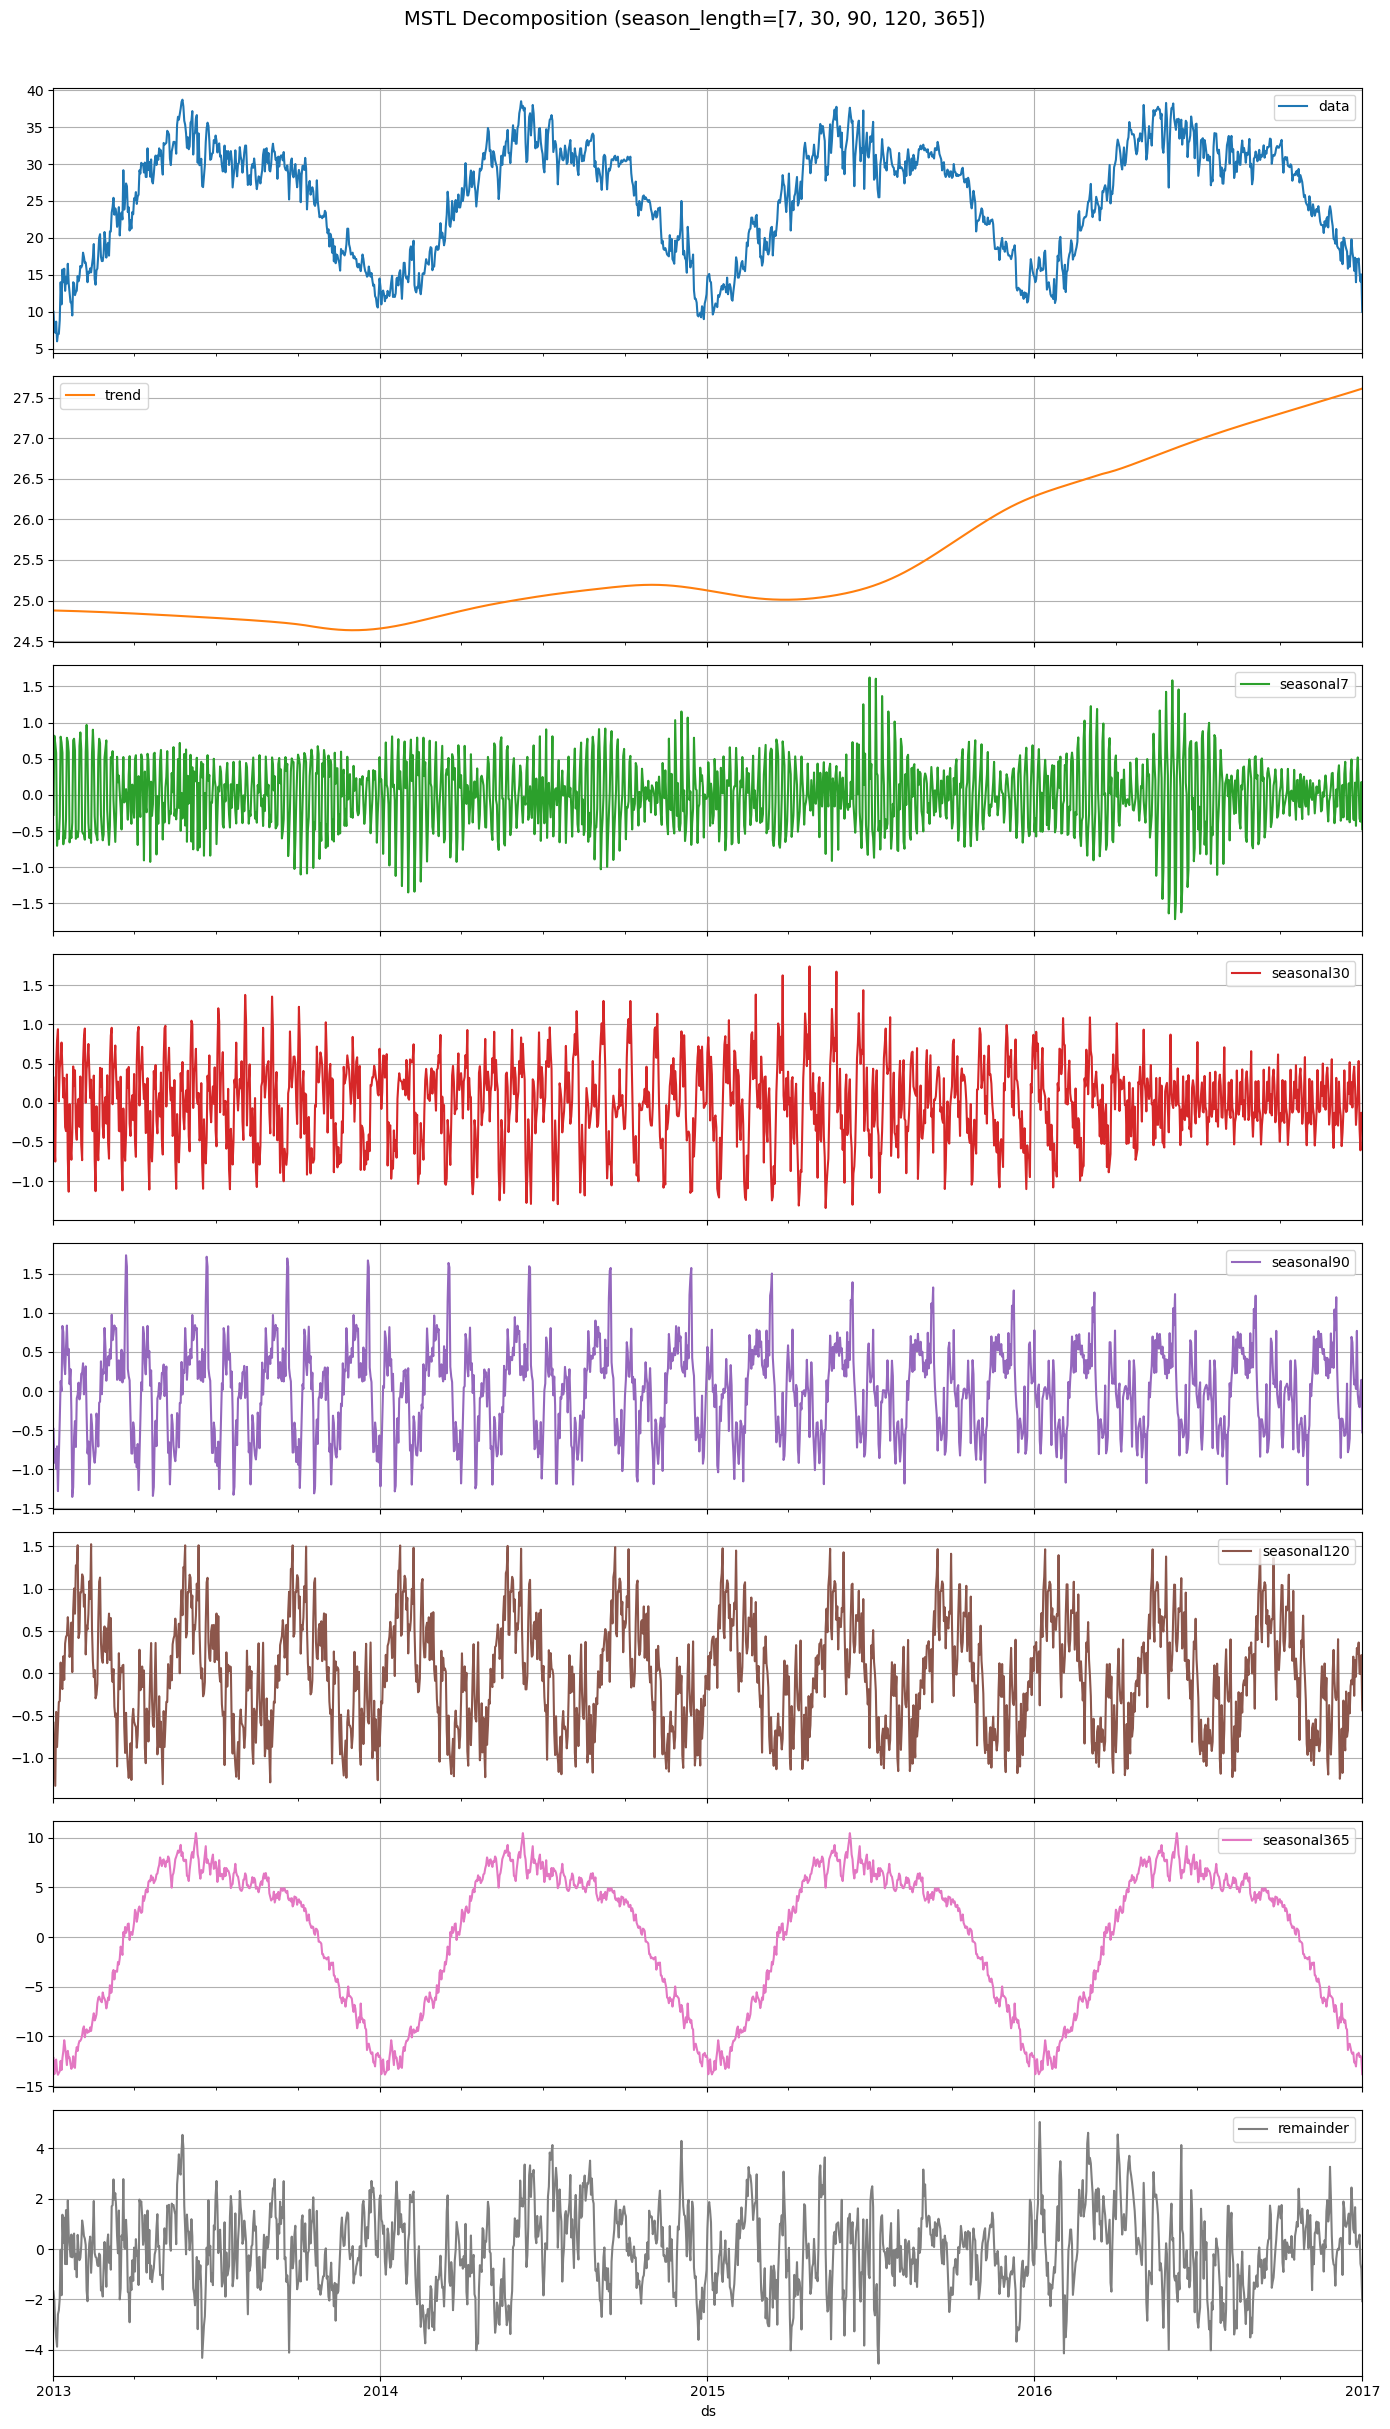

In [56]:
mstl_decompose.plot(x='ds', subplots=True, grid=True, figsize=(14, 3 * (mstl_decompose.shape[1] - 1)))
plt.suptitle('MSTL Decomposition (season_length=[7, 30, 90, 120, 365])', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; MSTL Plot Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The <strong>trend</strong> captures a slow-moving shift in the mean temperature across the full period.</li>
    <li>The <strong>365-day seasonal component</strong> is clearly the dominant and most stable cycle, matching the recurring annual summer-versus-winter temperature pattern.</li>
    <li>The shorter seasonal components look more like finer fluctuations around the dominant annual cycle.</li>
  </ul>
</div>


In [57]:
mstl_test_results = run_residual_tests(mstl_decompose['remainder'], 'MSTL')
mstl_residuals = mstl_test_results['residuals']
mstl_lb = mstl_test_results['lb_result']
mstl_jb_stat = mstl_test_results['jb_stat']
mstl_jb_pvalue = mstl_test_results['jb_pvalue']
mstl_jb_skew = mstl_test_results['jb_skew']
mstl_jb_kurt = mstl_test_results['jb_kurt']


=== MSTL Model: Ljung-Box Test ===
        lb_stat      lb_pvalue
1    858.508880  1.027374e-188
2   1379.825717  2.369478e-300
3   1678.259288   0.000000e+00
4   1893.298352   0.000000e+00
5   2042.676582   0.000000e+00
6   2121.647542   0.000000e+00
7   2142.996150   0.000000e+00
8   2172.905836   0.000000e+00
9   2211.257704   0.000000e+00
10  2260.057979   0.000000e+00

Reject H0: Residuals still contain autocorrelation — decomposition did not fully capture the temporal structure.

=== MSTL Model: Jarque-Bera Test ===
  Statistic : 1.0095
  p-value   : 0.6037
  Skewness  : 0.0305
  Kurtosis  : 2.8867

Fail to Reject H0: Residuals are normally distributed.


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; MSTL Residual Tests</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The <strong>Ljung-Box</strong> test still rejects no-autocorrelation, so even MSTL does not remove all temporal dependence.</li>
    <li>The <strong>Jarque-Bera</strong> p-value is <strong>0.6037</strong>, indicating that the residuals remain approximately normal.</li>
  </ul>
</div>


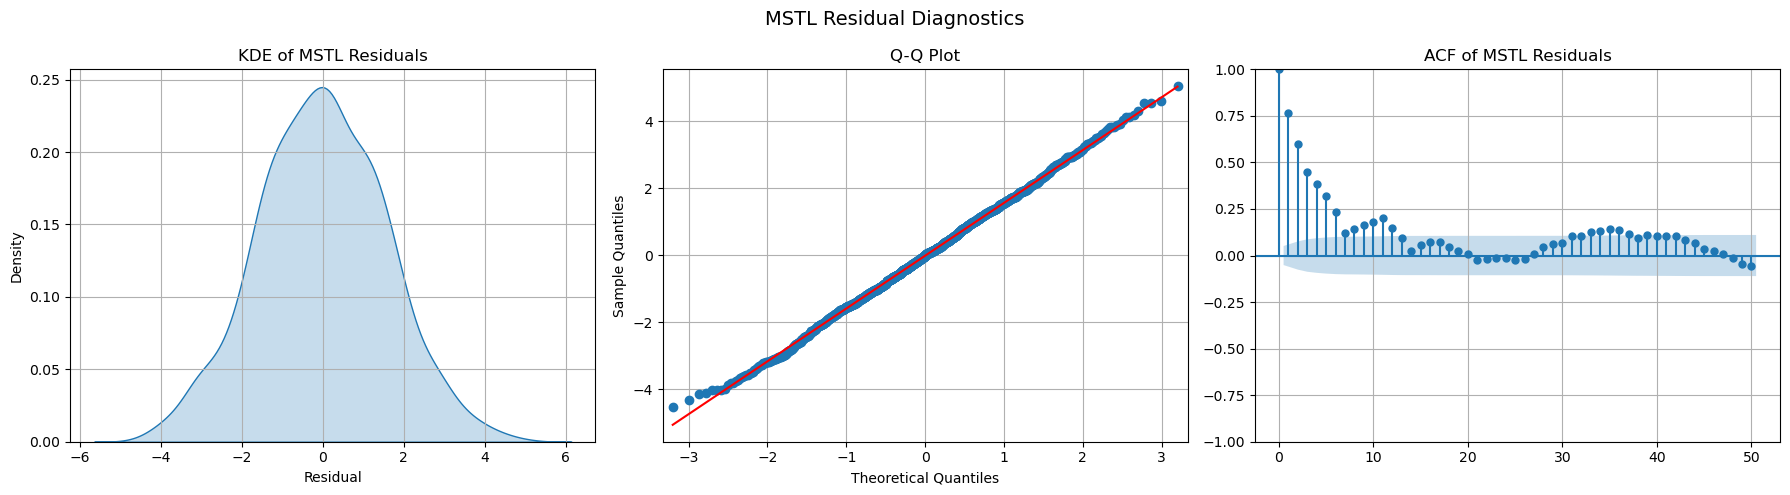


Metric                    Classical (Task 4)               MSTL
Residual Std Dev                      1.7754             1.5778
Residual Mean                         0.0159            -0.0158
JB p-value                            0.3387             0.6037


In [58]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MSTL Residual Diagnostics', fontsize=14)

sns.kdeplot(mstl_residuals, ax=axs[0], fill=True)
axs[0].set_title('KDE of MSTL Residuals')
axs[0].set_xlabel('Residual')

qqplot(mstl_residuals, line='s', ax=axs[1])
axs[1].set_title('Q-Q Plot')

plot_acf(mstl_residuals, ax=axs[2], lags=50)
axs[2].set_title('ACF of MSTL Residuals')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print(f"{'Metric':<25} {'Classical (Task 4)':>18} {'MSTL':>18}")
print("=" * 60)
print(f"{'Residual Std Dev':<25} {residuals.std():>18.4f} {mstl_residuals.std():>18.4f}")
print(f"{'Residual Mean':<25} {residuals.mean():>18.4f} {mstl_residuals.mean():>18.4f}")
print(f"{'JB p-value':<25} {jb_pvalue:>18.4f} {mstl_jb_pvalue:>18.4f}")
print("=" * 60)

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; MSTL vs Classical Decomposition</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><strong>MSTL residual std = 1.5778</strong> versus <strong>1.7754</strong> for classical decomposition.</li>
    <li>The lower residual variance confirms that modelling multiple seasonal scales extracts more systematic structure from the temperature series.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 15px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Final Conclusions</h2>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:10px;padding:20px;margin-bottom:20px;">
  <h3 style="color:#2e6da4;margin:0 0 12px;text-align:center;">Forecasting Results Summary (First 30 Test Days)</h3>
  <table border="0" cellpadding="10" cellspacing="0" style="border-collapse:collapse;width:100%;font-size:14px;color:#000;">
    <thead>
      <tr style="background:#2e6da4;color:white;">
        <th>Model</th><th>RMSE</th><th>Rank</th><th>Interpretation</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#eaf4ff;"><td>AutoETS &rarr; ETS(A,Ad,A)</td><td style="text-align:center;"><strong>2.6846</strong></td><td style="text-align:center;">1</td><td>Best short-term forecast; captured seasonal movement well on the 30-day horizon.</td></tr>
      <tr style="background:#f8faff;"><td>ETS (A, A, A)</td><td style="text-align:center;">3.8806</td><td style="text-align:center;">2</td><td>Strong short-term forecast, but weaker than AutoETS despite the full state-space formulation.</td></tr>
      <tr style="background:#eaf4ff;"><td>Holt-Winters</td><td style="text-align:center;">4.3699</td><td style="text-align:center;">3</td><td>Competitive seasonal baseline, but slightly less accurate over the first 30 days.</td></tr>
      <tr style="background:#f8faff;"><td>Mean Baseline</td><td style="text-align:center;">10.1010</td><td style="text-align:center;">4</td><td>Clearly inadequate because it ignores the strong seasonal structure.</td></tr>
    </tbody>
  </table>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0 0 10px;font-weight:bold;color:#2e6da4;">Conclusions:</p>
  <ol style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.8;">
    <li><strong>AutoETS is the strongest model on the 30-day evaluation window</strong>, selecting <strong>ETS(A,Ad,A)</strong> automatically and achieving the lowest RMSE.</li>
    <li><strong>ETS(A,A,A) and Holt-Winters both capture the annual seasonal pattern</strong>, but ETS gives the better short-term forecast of the two on this test window.</li>
    <li><strong>Residual diagnostics remain essential</strong> because even improved decompositions such as MSTL still leave statistically significant autocorrelation in the remainder.</li>
  </ol>
</div>
